# Credit Score Classification — Model Deployment Final Project
**Nama:** Syaqila Najwa Amalia Hambali
**NIM:** 2802488481  
**Dataset:** B  
**Course:** DTSC6012001 – Model Deployment | BINUS University 2025/2026


## 1. Import Libraries

In [2]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset

In [3]:
df = pd.read_csv('data_B.csv')
df.head()


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


## 3. Data Understanding

In [4]:
df.shape

(25000, 29)

In [5]:
print("Column names:", df.columns.tolist())

Column names: ['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  str    
 2   Customer_ID               25000 non-null  str    
 3   Month                     25000 non-null  str    
 4   Name                      22534 non-null  str    
 5   Age                       25000 non-null  str    
 6   SSN                       25000 non-null  str    
 7   Occupation                25000 non-null  str    
 8   Annual_Income             25000 non-null  str    
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  str    
 14  Type_of_Loan     

### Initial Data Understanding

Dataset yang digunakan memiliki 25.000 baris dan 29 kolom. Berdasarkan informasi awal, dataset ini berisi data performa kredit nasabah dengan target utama `Credit_Score`. Target ini menunjukkan bahwa permasalahan yang diselesaikan termasuk dalam supervised learning dengan pendekatan klasifikasi.

Beberapa kolom seperti `ID`, `Customer_ID`, `Name`, `SSN`, dan `Unnamed: 0` merupakan kolom identitas atau indeks tambahan yang tidak merepresentasikan pola kredit secara langsung. Oleh karena itu, kolom-kolom tersebut berpotensi dihapus pada tahap preprocessing agar model tidak mempelajari informasi yang tidak relevan.

Dari sisi tipe data, masih terdapat beberapa fitur numerik yang terbaca sebagai `str`, seperti `Age`, `Annual_Income`, `Num_of_Loan`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Outstanding_Debt`, `Amount_invested_monthly`, dan `Monthly_Balance`. Hal ini menunjukkan bahwa dataset masih membutuhkan proses data cleaning, terutama konversi tipe data dari object/string menjadi numerik.

Selain itu, beberapa kolom memiliki missing value, seperti `Monthly_Inhand_Salary`, `Name`, `Type_of_Loan`, `Credit_History_Age`, `Num_of_Delayed_Payment`, `Amount_invested_monthly`, `Num_Credit_Inquiries`, dan `Monthly_Balance`. Missing value ini perlu ditangani pada tahap preprocessing agar model machine learning dapat dilatih dengan baik.

Secara umum, dataset belum siap langsung digunakan untuk modelling karena masih terdapat kolom identitas, missing value, fitur numerik yang belum sesuai tipe datanya, dan kemungkinan nilai tidak valid pada beberapa kolom. Oleh karena itu, tahap berikutnya adalah melakukan eksplorasi lebih detail terhadap missing value, distribusi target, dan nilai unik pada fitur kategorikal maupun numerik.

In [7]:
df.isnull().sum()

Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2466
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3756
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2848
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit           0
Num_Credit_Inquiries         490
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2292
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1060
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64

### Missing Value Analysis

Berdasarkan hasil pengecekan missing value, terdapat beberapa kolom yang memiliki nilai kosong. Kolom dengan missing value terbesar adalah `Monthly_Inhand_Salary` sebanyak 3.756 data atau sekitar 15,02% dari total dataset. Selain itu, `Type_of_Loan` memiliki 2.848 missing value, `Name` memiliki 2.466 missing value, dan `Credit_History_Age` memiliki 2.292 missing value.

Missing value juga ditemukan pada beberapa fitur yang relevan untuk analisis kredit, seperti `Num_of_Delayed_Payment`, `Amount_invested_monthly`, `Num_Credit_Inquiries`, dan `Monthly_Balance`. Karena fitur-fitur tersebut berpotensi memengaruhi performa kredit nasabah, maka nilai kosongnya perlu ditangani dengan strategi preprocessing yang tepat.

Kolom `Name` tidak terlalu relevan untuk modelling karena hanya berisi identitas nasabah, sehingga kolom ini dapat dihapus bersama kolom identitas lain seperti `ID`, `Customer_ID`, `SSN`, dan `Unnamed: 0`. Untuk kolom numerik yang memiliki missing value, imputasi dapat dilakukan menggunakan median karena lebih robust terhadap outlier. Sementara itu, untuk kolom kategorikal seperti `Type_of_Loan`, missing value dapat ditangani menggunakan kategori khusus seperti `Unknown`.

Secara keseluruhan, dataset masih membutuhkan proses data cleaning sebelum digunakan untuk modelling. Penanganan missing value penting dilakukan agar model dapat mempelajari pola data dengan lebih stabil dan tidak mengalami error saat proses training.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Credit_Score"].value_counts()

Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64

## 4. Data Cleaning

### 4.1 Drop kolom identitas

In [10]:
# Drop Kolom
df_clean = df.copy()

drop_cols = ["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN"]
df_clean = df_clean.drop(columns=drop_cols)

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  str    
 1   Age                       25000 non-null  str    
 2   Occupation                25000 non-null  str    
 3   Annual_Income             25000 non-null  str    
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  str    
 9   Type_of_Loan              22152 non-null  str    
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  str    
 12  Changed_Credit_Limit      25000 non-null  str    
 13  Num_Credit_Inquiries      24510 non-null  float64
 14  Credit_Mix       

### Removing Irrelevant Identity Columns

Pada tahap awal preprocessing, beberapa kolom identitas dihapus dari dataset, yaitu `Unnamed: 0`, `ID`, `Customer_ID`, `Name`, dan `SSN`. Kolom-kolom tersebut tidak digunakan dalam proses modelling karena hanya berfungsi sebagai penanda identitas atau indeks tambahan, bukan sebagai fitur yang menjelaskan performa kredit nasabah.

Setelah kolom tersebut dihapus, jumlah fitur berkurang dari 29 kolom menjadi 24 kolom. Dataset masih mempertahankan fitur-fitur yang lebih relevan terhadap analisis kredit, seperti pendapatan, jumlah rekening bank, jumlah kartu kredit, jumlah pinjaman, riwayat keterlambatan pembayaran, outstanding debt, credit utilization, dan target `Credit_Score`.

Namun, beberapa kolom numerik masih terbaca sebagai tipe data string, seperti `Age`, `Annual_Income`, `Num_of_Loan`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Outstanding_Debt`, `Amount_invested_monthly`, dan `Monthly_Balance`. Oleh karena itu, tahap berikutnya adalah membersihkan karakter tidak valid dan mengubah kolom-kolom tersebut menjadi tipe data numerik.


### 4.2 Convert numeric columns dari string ke angka

In [11]:
# Cleaning
num_str_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in num_str_cols:
    df_clean[col] = df_clean[col].astype(str).str.replace("_", "", regex=False)
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")


df_clean[num_str_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      25000 non-null  int64  
 1   Annual_Income            25000 non-null  float64
 2   Num_of_Loan              25000 non-null  int64  
 3   Num_of_Delayed_Payment   23267 non-null  float64
 4   Changed_Credit_Limit     24468 non-null  float64
 5   Outstanding_Debt         25000 non-null  float64
 6   Amount_invested_monthly  23940 non-null  float64
 7   Monthly_Balance          24699 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 1.5 MB


### Numeric Data Type Conversion

Beberapa kolom numerik pada dataset awal masih terbaca sebagai string karena memiliki karakter tambahan seperti underscore (`_`). Setelah karakter tersebut dibersihkan dan kolom dikonversi ke tipe numerik, fitur seperti `Age`, `Annual_Income`, `Num_of_Loan`, `Outstanding_Debt`, `Amount_invested_monthly`, dan `Monthly_Balance` sudah dapat digunakan untuk proses analisis dan modelling.

Pada tahap ini, beberapa nilai berubah menjadi missing value karena terdapat data yang tidak valid dan tidak dapat dikonversi menjadi angka. Missing value tersebut akan ditangani pada tahap preprocessing berikutnya.


### 4.3 Convert Credit History Age

In [12]:
years = df_clean["Credit_History_Age"].str.extract(r"(\d+)\s+Years").astype(float)
months = df_clean["Credit_History_Age"].str.extract(r"(\d+)\s+Months").astype(float)

df_clean["Credit_History_Age_Months"] = (years[0] * 12) + months[0]

df_clean = df_clean.drop(columns=["Credit_History_Age"])

df_clean[["Credit_History_Age_Months"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 1 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Credit_History_Age_Months  22708 non-null  float64
dtypes: float64(1)
memory usage: 195.4 KB


In [13]:
df_clean[["Credit_History_Age_Months"]].head()

,Credit_History_Age_Months
0,38.0
1,153.0
2,145.0
3,330.0
4,345.0


### Credit History Age Conversion

Kolom `Credit_History_Age` awalnya berbentuk teks, sehingga belum bisa langsung digunakan untuk modelling. Kolom tersebut dikonversi menjadi `Credit_History_Age_Months` agar riwayat kredit nasabah direpresentasikan dalam bentuk numerik total bulan. Setelah dikonversi, fitur ini menjadi lebih mudah digunakan dalam analisis dan training model.


### 4.4 Check Missing Values After Conversion

In [14]:
df_clean.isnull().sum().sort_values(ascending=False)

Monthly_Inhand_Salary        3756
Type_of_Loan                 2848
Credit_History_Age_Months    2292
Num_of_Delayed_Payment       1733
Amount_invested_monthly      1060
Changed_Credit_Limit          532
Num_Credit_Inquiries          490
Monthly_Balance               301
Interest_Rate                   0
Num_Credit_Card                 0
Num_Bank_Accounts               0
Annual_Income                   0
Age                             0
Occupation                      0
Month                           0
Delay_from_due_date             0
Outstanding_Debt                0
Credit_Mix                      0
Num_of_Loan                     0
Credit_Utilization_Ratio        0
Total_EMI_per_month             0
Payment_of_Min_Amount           0
Payment_Behaviour               0
Credit_Score                    0
dtype: int64

### Missing Value After Data Type Conversion

Setelah proses konversi tipe data, missing value masih ditemukan pada beberapa fitur numerik dan kategorikal. Missing value pada kolom numerik akan ditangani menggunakan median karena lebih stabil terhadap outlier. Sementara itu, missing value pada kolom kategorikal seperti `Type_of_Loan` akan diisi dengan kategori `Unknown`.

Tahap ini dilakukan agar dataset tidak memiliki nilai kosong sebelum masuk ke proses eksplorasi lanjutan dan modelling.


### 4.5 Handle Missing Values

In [15]:
numeric_missing_cols = [
    "Monthly_Inhand_Salary",
    "Credit_History_Age_Months",
    "Num_of_Delayed_Payment",
    "Amount_invested_monthly",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Monthly_Balance"
]

for col in numeric_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean["Type_of_Loan"] = df_clean["Type_of_Loan"].fillna("Unknown")

df_clean.isnull().sum().sort_values(ascending=False)

Month                        0
Age                          0
Occupation                   0
Annual_Income                0
Monthly_Inhand_Salary        0
Num_Bank_Accounts            0
Num_Credit_Card              0
Interest_Rate                0
Num_of_Loan                  0
Type_of_Loan                 0
Delay_from_due_date          0
Num_of_Delayed_Payment       0
Changed_Credit_Limit         0
Num_Credit_Inquiries         0
Credit_Mix                   0
Outstanding_Debt             0
Credit_Utilization_Ratio     0
Payment_of_Min_Amount        0
Total_EMI_per_month          0
Amount_invested_monthly      0
Payment_Behaviour            0
Monthly_Balance              0
Credit_Score                 0
Credit_History_Age_Months    0
dtype: int64

### Missing Value Handling Result

Setelah dilakukan imputasi, seluruh missing value pada dataset berhasil ditangani. Fitur numerik diisi menggunakan nilai median, sedangkan fitur kategorikal `Type_of_Loan` diisi dengan kategori `Unknown`. Dengan demikian, dataset sudah tidak memiliki nilai kosong dan dapat dilanjutkan ke tahap pengecekan nilai tidak valid.


### 4.6 Clean Invalid Categorical Values


In [16]:
# cek dirty values di kolom kategorikal
cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    print("\n", col)
    print(df_clean[col].value_counts().head(15))


 Month
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

 Occupation
Occupation
_______          1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Name: count, dtype: int64

 Type_of_Loan
Type_of_Loan
Unknown                                  2848
Not Specified                             367
Student Loan                              317
Credit-Builder Loan                       315
Personal Loan                             304
Debt Consolidation Loan                   301
Payday Loan                               285
Auto Loan                                 282
Home Equity Loan                          281
Mo

### Handling Invalid Categorical Values

Beberapa fitur kategorikal memiliki nilai tidak valid, seperti `_______` pada `Occupation`, `_` pada `Credit_Mix`, `!@9#%8` pada `Payment_Behaviour`, dan `NM` pada `Payment_of_Min_Amount`. Nilai-nilai tersebut diganti menjadi `Unknown` agar tetap dapat digunakan sebagai kategori tanpa menghilangkan baris data.

Setelah proses ini, nilai kategorikal menjadi lebih konsisten dan siap digunakan pada tahap encoding sebelum modelling.


In [17]:
df_clean["Occupation"] = df_clean["Occupation"].replace("_______", "Unknown")
df_clean["Credit_Mix"] = df_clean["Credit_Mix"].replace("_", "Unknown")
df_clean["Payment_Behaviour"] = df_clean["Payment_Behaviour"].replace("!@9#%8", "Unknown")
df_clean["Payment_of_Min_Amount"] = df_clean["Payment_of_Min_Amount"].replace("NM", "Unknown")

print(df_clean["Occupation"].value_counts().head())
print(df_clean["Credit_Mix"].value_counts())
print(df_clean["Payment_Behaviour"].value_counts())
print(df_clean["Payment_of_Min_Amount"].value_counts())

Occupation
Unknown       1792
Lawyer        1634
Scientist     1608
Accountant    1592
Engineer      1572
Name: count, dtype: int64
Credit_Mix
Standard    9075
Good        6042
Unknown     5172
Bad         4711
Name: count, dtype: int64
Payment_Behaviour
Low_spent_Small_value_payments      6480
High_spent_Medium_value_payments    4445
Low_spent_Medium_value_payments     3433
High_spent_Large_value_payments     3396
High_spent_Small_value_payments     2817
Low_spent_Large_value_payments      2526
Unknown                             1903
Name: count, dtype: int64
Payment_of_Min_Amount
Yes        13043
No          8875
Unknown     3082
Name: count, dtype: int64


### Categorical Value Cleaning Result

Nilai tidak valid pada fitur kategorikal telah diganti menjadi `Unknown`. Contohnya adalah `_______` pada `Occupation`, `_` pada `Credit_Mix`, `!@9#%8` pada `Payment_Behaviour`, dan `NM` pada `Payment_of_Min_Amount`.

Dengan proses ini, fitur kategorikal menjadi lebih konsisten dan siap digunakan untuk tahap encoding sebelum training model.


### 4.7 Check Invalid Numeric Values

In [18]:
# cek nilai numerik yang tidak masuk akal / outlier awal
df_clean.select_dtypes(include=["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,1.170904e+02,7.167958e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.666000e+03
Annual_Income,25000.0,1.848748e+05,1.481741e+06,7.006035e+03,19548.868750,37824.960000,73020.540000,2.417715e+07
Monthly_Inhand_Salary,25000.0,4.039982e+03,2.945528e+03,3.036454e+02,1804.031667,3118.399167,5390.500625,1.520463e+04
Num_Bank_Accounts,25000.0,1.618932e+01,1.139799e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,25000.0,2.220480e+01,1.286359e+02,0.000000e+00,4.000000,5.000000,7.000000,1.495000e+03
Interest_Rate,25000.0,7.288372e+01,4.645336e+02,1.000000e+00,8.000000,13.000000,20.000000,5.774000e+03
Num_of_Loan,25000.0,2.876120e+00,6.187944e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,25000.0,2.102936e+01,1.481596e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,25000.0,3.177604e+01,2.340165e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,25000.0,1.034316e+01,6.703808e+00,-6.490000e+00,5.420000,9.370000,14.612500,3.649000e+01


In [19]:
checks = {
    "Age < 0": (df_clean["Age"] < 0).sum(),
    "Age > 100": (df_clean["Age"] > 100).sum(),
    "Annual_Income <= 0": (df_clean["Annual_Income"] <= 0).sum(),
    "Monthly_Inhand_Salary <= 0": (df_clean["Monthly_Inhand_Salary"] <= 0).sum(),
    "Num_Bank_Accounts < 0": (df_clean["Num_Bank_Accounts"] < 0).sum(),
    "Num_Bank_Accounts > 20": (df_clean["Num_Bank_Accounts"] > 20).sum(),
    "Num_Credit_Card < 0": (df_clean["Num_Credit_Card"] < 0).sum(),
    "Num_Credit_Card > 20": (df_clean["Num_Credit_Card"] > 20).sum(),
    "Interest_Rate < 0": (df_clean["Interest_Rate"] < 0).sum(),
    "Interest_Rate > 100": (df_clean["Interest_Rate"] > 100).sum(),
    "Num_of_Loan < 0": (df_clean["Num_of_Loan"] < 0).sum(),
    "Num_of_Loan > 20": (df_clean["Num_of_Loan"] > 20).sum(),
    "Num_of_Delayed_Payment < 0": (df_clean["Num_of_Delayed_Payment"] < 0).sum(),
    "Num_of_Delayed_Payment > 100": (df_clean["Num_of_Delayed_Payment"] > 100).sum(),
    "Outstanding_Debt < 0": (df_clean["Outstanding_Debt"] < 0).sum(),
    "Credit_Utilization_Ratio < 0": (df_clean["Credit_Utilization_Ratio"] < 0).sum(),
    "Credit_Utilization_Ratio > 100": (df_clean["Credit_Utilization_Ratio"] > 100).sum(),
    "Total_EMI_per_month < 0": (df_clean["Total_EMI_per_month"] < 0).sum(),
    "Amount_invested_monthly < 0": (df_clean["Amount_invested_monthly"] < 0).sum(),
    "Monthly_Balance < 0": (df_clean["Monthly_Balance"] < 0).sum(),
    "Credit_History_Age_Months < 0": (df_clean["Credit_History_Age_Months"] < 0).sum()
}

pd.DataFrame(checks.items(), columns=["Check", "Count"])

,Check,Count
0,Age < 0,217
1,Age > 100,502
2,Annual_Income <= 0,0
3,Monthly_Inhand_Salary <= 0,0
4,Num_Bank_Accounts < 0,6
5,Num_Bank_Accounts > 20,292
6,Num_Credit_Card < 0,0
7,Num_Credit_Card > 20,554
8,Interest_Rate < 0,0
9,Interest_Rate > 100,515


### Invalid Numeric Value Analysis

Berdasarkan hasil pengecekan statistik deskriptif, beberapa fitur numerik memiliki nilai yang tidak realistis. Contohnya adalah `Age` yang memiliki nilai negatif dan nilai sangat besar, `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, dan `Num_of_Loan` yang memiliki nilai maksimum terlalu ekstrem.

Nilai-nilai tersebut dianggap tidak valid karena tidak sesuai dengan konteks data kredit nasabah. Oleh karena itu, nilai yang tidak realistis akan diganti menjadi missing value, lalu diisi kembali menggunakan median agar tidak terlalu dipengaruhi oleh outlier.


### 4.8 Handle Invalid Numeric Values

In [20]:
df_clean.loc[(df_clean["Age"] < 0) | (df_clean["Age"] > 100), "Age"] = np.nan
df_clean.loc[(df_clean["Num_Bank_Accounts"] < 0) | (df_clean["Num_Bank_Accounts"] > 20), "Num_Bank_Accounts"] = np.nan
df_clean.loc[(df_clean["Num_Credit_Card"] < 0) | (df_clean["Num_Credit_Card"] > 20), "Num_Credit_Card"] = np.nan
df_clean.loc[(df_clean["Interest_Rate"] < 0) | (df_clean["Interest_Rate"] > 100), "Interest_Rate"] = np.nan
df_clean.loc[(df_clean["Num_of_Loan"] < 0) | (df_clean["Num_of_Loan"] > 20), "Num_of_Loan"] = np.nan
df_clean.loc[(df_clean["Num_of_Delayed_Payment"] < 0) | (df_clean["Num_of_Delayed_Payment"] > 100), "Num_of_Delayed_Payment"] = np.nan
df_clean.loc[df_clean["Monthly_Balance"] < 0, "Monthly_Balance"] = np.nan

invalid_cols = [
    "Age",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Monthly_Balance"
]

for col in invalid_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [21]:
checks_after = {
    "Age < 0": (df_clean["Age"] < 0).sum(),
    "Age > 100": (df_clean["Age"] > 100).sum(),
    "Num_Bank_Accounts < 0": (df_clean["Num_Bank_Accounts"] < 0).sum(),
    "Num_Bank_Accounts > 20": (df_clean["Num_Bank_Accounts"] > 20).sum(),
    "Num_Credit_Card < 0": (df_clean["Num_Credit_Card"] < 0).sum(),
    "Num_Credit_Card > 20": (df_clean["Num_Credit_Card"] > 20).sum(),
    "Interest_Rate < 0": (df_clean["Interest_Rate"] < 0).sum(),
    "Interest_Rate > 100": (df_clean["Interest_Rate"] > 100).sum(),
    "Num_of_Loan < 0": (df_clean["Num_of_Loan"] < 0).sum(),
    "Num_of_Loan > 20": (df_clean["Num_of_Loan"] > 20).sum(),
    "Num_of_Delayed_Payment < 0": (df_clean["Num_of_Delayed_Payment"] < 0).sum(),
    "Num_of_Delayed_Payment > 100": (df_clean["Num_of_Delayed_Payment"] > 100).sum(),
    "Monthly_Balance < 0": (df_clean["Monthly_Balance"] < 0).sum()
}

pd.DataFrame(checks_after.items(), columns=["Check", "Count"])

,Check,Count
0,Age < 0,0
1,Age > 100,0
2,Num_Bank_Accounts < 0,0
3,Num_Bank_Accounts > 20,0
4,Num_Credit_Card < 0,0
5,Num_Credit_Card > 20,0
6,Interest_Rate < 0,0
7,Interest_Rate > 100,0
8,Num_of_Loan < 0,0
9,Num_of_Loan > 20,0


### Invalid Numeric Value Handling Result

Nilai numerik yang tidak realistis sudah berhasil ditangani. Beberapa nilai seperti umur negatif, umur lebih dari 100, jumlah akun bank terlalu besar, jumlah kartu kredit ekstrem, interest rate terlalu tinggi, jumlah pinjaman negatif, serta monthly balance negatif telah diganti menjadi missing value dan diisi kembali menggunakan median.

Setelah proses ini, seluruh pengecekan nilai invalid menghasilkan jumlah 0, sehingga dataset sudah lebih bersih dan siap digunakan untuk tahap EDA lanjutan.


### 4.9 Final Cleaning Check

In [22]:
print("Shape:", df_clean.shape)

print("Missing values:", df_clean.isnull().sum().sum())

print("Duplicate rows:", df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nTarget distribution:")
print(df_clean["Credit_Score"].value_counts())

Shape: (25000, 24)
Missing values: 0
Duplicate rows: 0

Data types:
Month                            str
Age                          float64
Occupation                       str
Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts            float64
Num_Credit_Card              float64
Interest_Rate                float64
Num_of_Loan                  float64
Type_of_Loan                     str
Delay_from_due_date            int64
Num_of_Delayed_Payment       float64
Changed_Credit_Limit         float64
Num_Credit_Inquiries         float64
Credit_Mix                       str
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Payment_of_Min_Amount            str
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Payment_Behaviour                str
Monthly_Balance              float64
Credit_Score                     str
Credit_History_Age_Months    float64
dtype: object

Target distribution:
Credit_S

### Final Data Cleaning Check

Setelah proses cleaning, dataset memiliki 25.000 baris dan 24 kolom. Seluruh missing value dan duplicate rows sudah berhasil ditangani. Selain itu, beberapa fitur numerik yang sebelumnya memiliki nilai tidak valid juga sudah dibersihkan.

Dengan kondisi ini, dataset sudah lebih siap untuk digunakan pada tahap EDA lanjutan dan proses modelling.


## 5. Exploratory Data Analysis

### 5.1 Target Distribution

Credit_Score
Standard    13257
Poor         7197
Good         4546
Name: count, dtype: int64


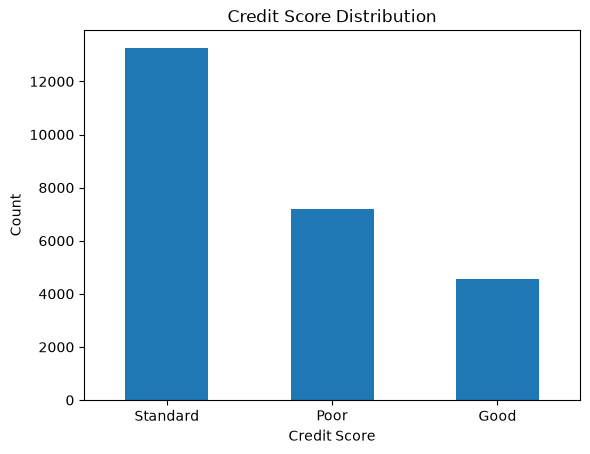

In [23]:
print(df_clean["Credit_Score"].value_counts())

df_clean["Credit_Score"].value_counts().plot(kind="bar")

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### Credit Score Distribution

Distribusi target `Credit_Score` terdiri dari tiga kelas, yaitu `Standard`, `Poor`, dan `Good`. Berdasarkan visualisasi, kelas `Standard` memiliki jumlah data paling banyak, diikuti oleh kelas `Poor`, sedangkan kelas `Good` memiliki jumlah data paling sedikit.

Hal ini menunjukkan adanya ketidakseimbangan kelas pada dataset. Oleh karena itu, evaluasi model tidak cukup hanya menggunakan accuracy, tetapi juga perlu melihat precision, recall, F1-score, dan confusion matrix agar performa model pada setiap kelas dapat dianalisis dengan lebih adil.


### 5.2 Numerical Features by Target

In [24]:
# cek rata-rata fitur numerik berdasarkan target
df_clean.groupby("Credit_Score")[[
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Monthly_Balance",
    "Credit_History_Age_Months"
]].mean().round(2)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Credit_Utilization_Ratio,Monthly_Balance,Credit_History_Age_Months
Credit_Score,,,,,,,,,,,,,
Good,36.28,182009.48,5030.91,3.47,4.15,7.72,2.24,10.79,9.15,795.27,32.55,470.83,279.48
Poor,31.32,161118.27,3377.93,6.53,6.60,20.10,4.68,29.81,15.81,2058.10,32.03,347.54,173.79
Standard,33.50,198754.29,4059.60,5.39,5.40,13.80,3.30,19.77,13.70,1284.74,32.35,406.29,227.51


### Numerical Features by Credit Score

Berdasarkan rata-rata fitur numerik pada setiap kelas `Credit_Score`, terlihat bahwa nasabah dengan kredit `Good` cenderung memiliki kondisi keuangan yang lebih baik. Kelas ini memiliki `Monthly_Inhand_Salary` dan `Monthly_Balance` yang lebih tinggi, serta `Outstanding_Debt`, `Interest_Rate`, `Num_of_Loan`, dan `Delay_from_due_date` yang lebih rendah.

Sebaliknya, kelas `Poor` memiliki pola yang lebih berisiko, seperti rata-rata `Outstanding_Debt`, `Interest_Rate`, jumlah pinjaman, jumlah keterlambatan pembayaran, dan keterlambatan jatuh tempo yang lebih tinggi. Hal ini menunjukkan bahwa fitur-fitur tersebut cukup relevan dalam membedakan kualitas kredit nasabah.


### 5.3 Categorical Features by Target

In [25]:
# cek fitur kategorikal terhadap target
pd.crosstab(df_clean["Credit_Mix"], df_clean["Credit_Score"], normalize="index").round(2)

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,0.01,0.60,0.38
Good,0.50,0.16,0.34
Standard,0.06,0.21,0.73
Unknown,0.18,0.28,0.53


In [26]:
pd.crosstab(df_clean["Payment_of_Min_Amount"], df_clean["Credit_Score"], normalize="index").round(2)

Credit_Score,Good,Poor,Standard
Payment_of_Min_Amount,,,
No,0.39,0.13,0.48
Unknown,0.20,0.28,0.51
Yes,0.03,0.40,0.57


In [27]:
pd.crosstab(df_clean["Payment_Behaviour"], df_clean["Credit_Score"], normalize="index").round(2)

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,0.23,0.21,0.55
High_spent_Medium_value_payments,0.21,0.24,0.55
High_spent_Small_value_payments,0.18,0.27,0.55
Low_spent_Large_value_payments,0.19,0.28,0.54
Low_spent_Medium_value_payments,0.19,0.30,0.51
Low_spent_Small_value_payments,0.13,0.35,0.52
Unknown,0.18,0.31,0.51


### Categorical Features by Credit Score

Berdasarkan hasil crosstab, fitur `Credit_Mix` memiliki hubungan yang cukup jelas dengan `Credit_Score`. Nasabah dengan `Credit_Mix` kategori `Good` lebih banyak masuk ke kelas `Good`, sedangkan kategori `Bad` didominasi oleh kelas `Poor`. Hal ini menunjukkan bahwa `Credit_Mix` merupakan fitur yang relevan untuk membedakan performa kredit nasabah.

Pada fitur `Payment_of_Min_Amount`, nasabah yang tidak hanya membayar minimum payment (`No`) memiliki proporsi kelas `Good` lebih tinggi. Sebaliknya, nasabah dengan nilai `Yes` memiliki proporsi kelas `Poor` yang lebih besar. Fitur ini menunjukkan bahwa kebiasaan pembayaran minimum dapat berkaitan dengan kualitas kredit.

Sementara itu, `Payment_Behaviour` juga menunjukkan pola tertentu, meskipun tidak sekuat `Credit_Mix`. Kategori seperti `Low_spent_Small_value_payments` memiliki proporsi kelas `Poor` yang lebih tinggi dibandingkan kategori lainnya.


### 5.4 Numerical Distribution

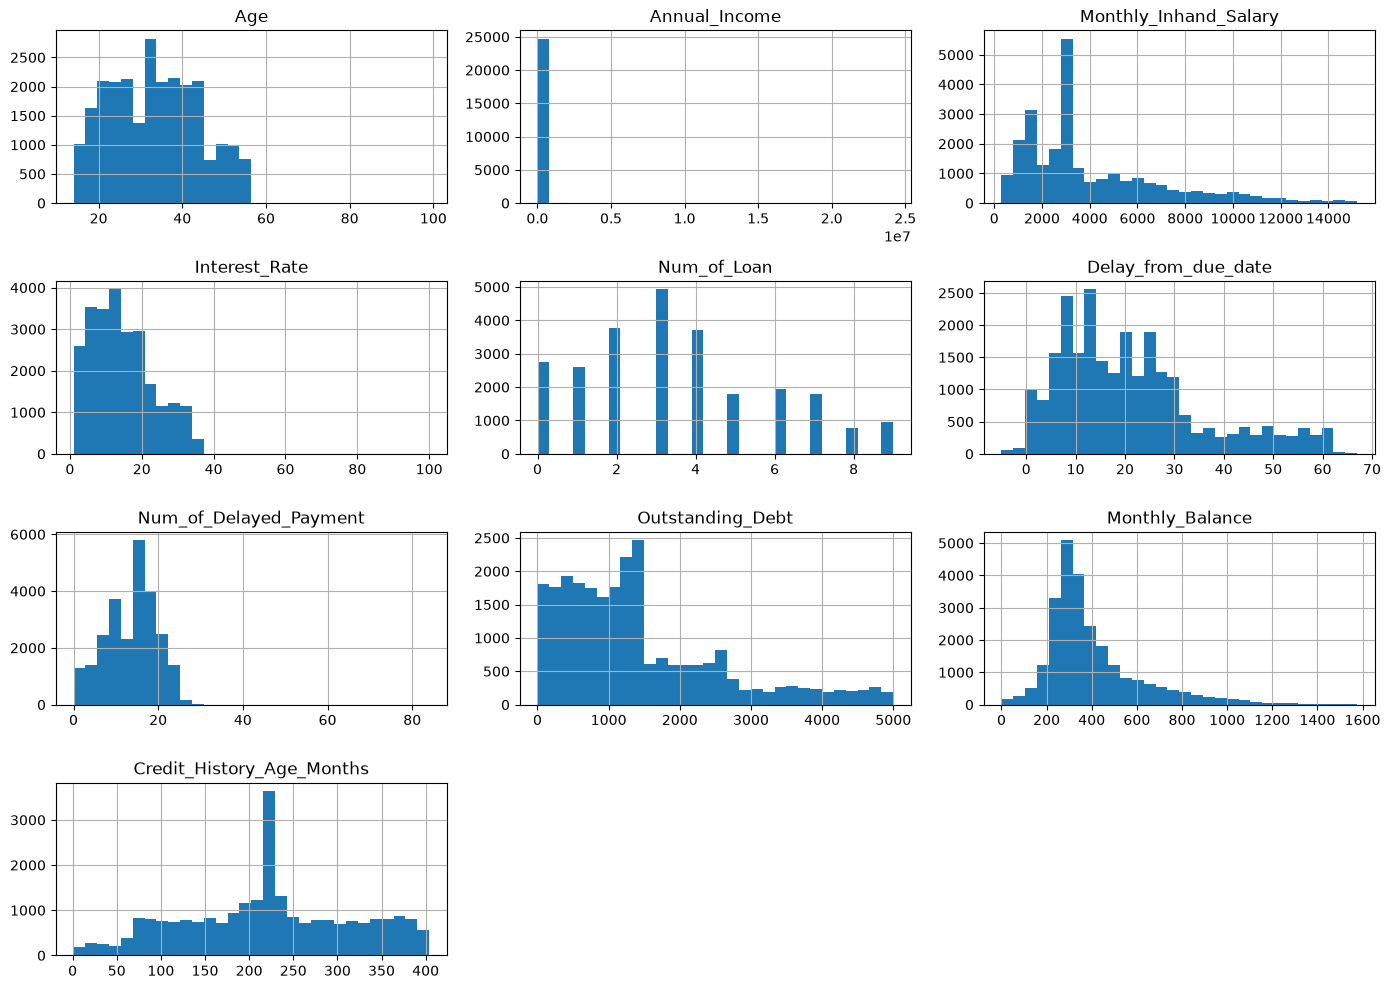

In [28]:
num_plot_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Monthly_Balance",
    "Credit_History_Age_Months"
]

df_clean[num_plot_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

### Numerical Distribution Analysis

Berdasarkan histogram, beberapa fitur numerik memiliki distribusi yang tidak merata. Fitur seperti `Annual_Income`, `Monthly_Inhand_Salary`, dan `Monthly_Balance` cenderung right-skewed, yang berarti sebagian besar nasabah berada pada nilai rendah hingga menengah, sementara sebagian kecil memiliki nilai yang jauh lebih tinggi.

Fitur seperti `Interest_Rate`, `Delay_from_due_date`, dan `Outstanding_Debt` juga menunjukkan variasi yang cukup besar antar nasabah. Sementara itu, `Credit_History_Age_Months` memiliki konsentrasi cukup tinggi di sekitar nilai tengah, yang dapat terjadi karena adanya imputasi median pada missing value sebelumnya.

Secara umum, distribusi ini menunjukkan bahwa fitur numerik memiliki skala dan pola sebaran yang berbeda-beda, sehingga scaling diperlukan sebelum modelling, terutama untuk model yang sensitif terhadap skala fitur.


### 5.5 Boxplot for Outlier Visualization

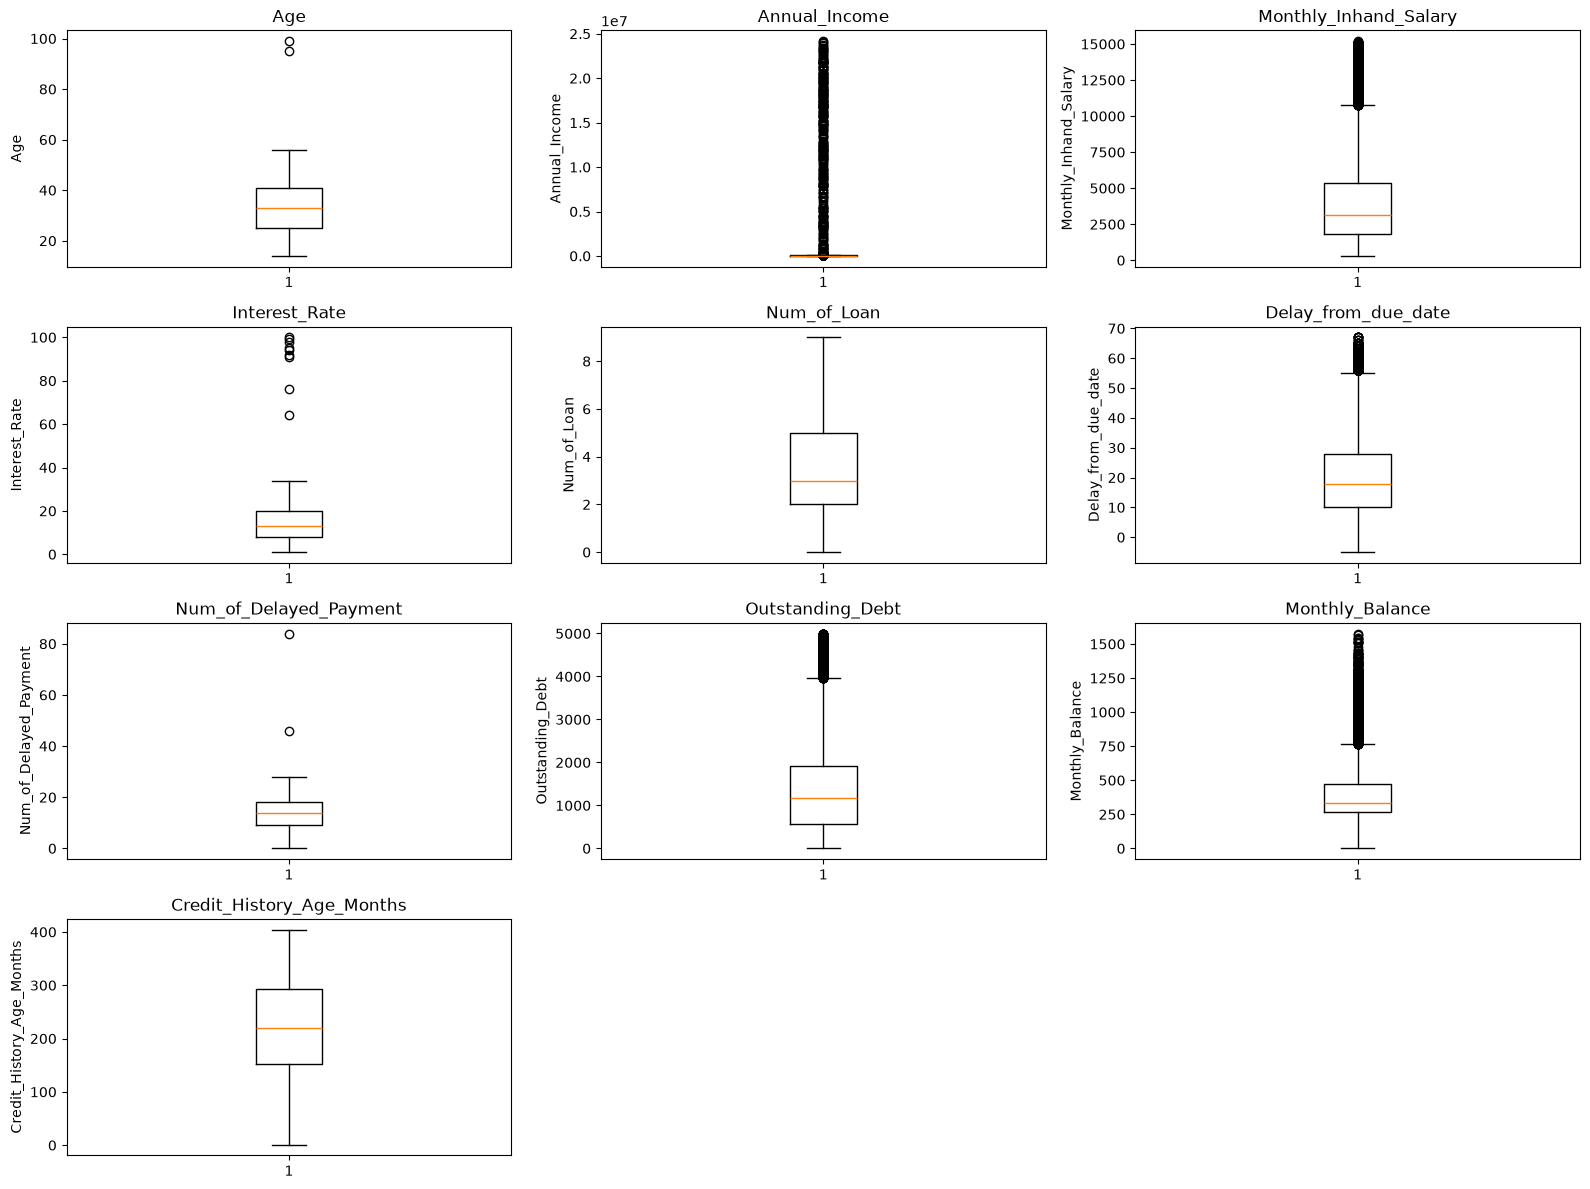

In [29]:
num_plot_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Outstanding_Debt",
    "Monthly_Balance",
    "Credit_History_Age_Months"
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_plot_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df_clean[col])
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Boxplot Outlier Analysis

Berdasarkan boxplot, beberapa fitur seperti `Annual_Income`, `Monthly_Inhand_Salary`, `Interest_Rate`, `Delay_from_due_date`, `Outstanding_Debt`, dan `Monthly_Balance` masih memiliki nilai ekstrem. Namun, nilai yang tidak valid sudah dibersihkan pada tahap sebelumnya, sehingga nilai ekstrem yang tersisa masih dapat dianggap sebagai variasi data nasabah.

Fitur `Num_of_Loan` dan `Credit_History_Age_Months` terlihat lebih stabil dibandingkan fitur lainnya. Karena masih terdapat perbedaan skala antar fitur numerik, proses scaling tetap diperlukan sebelum modelling.


### 5.6 Correlation Analysis

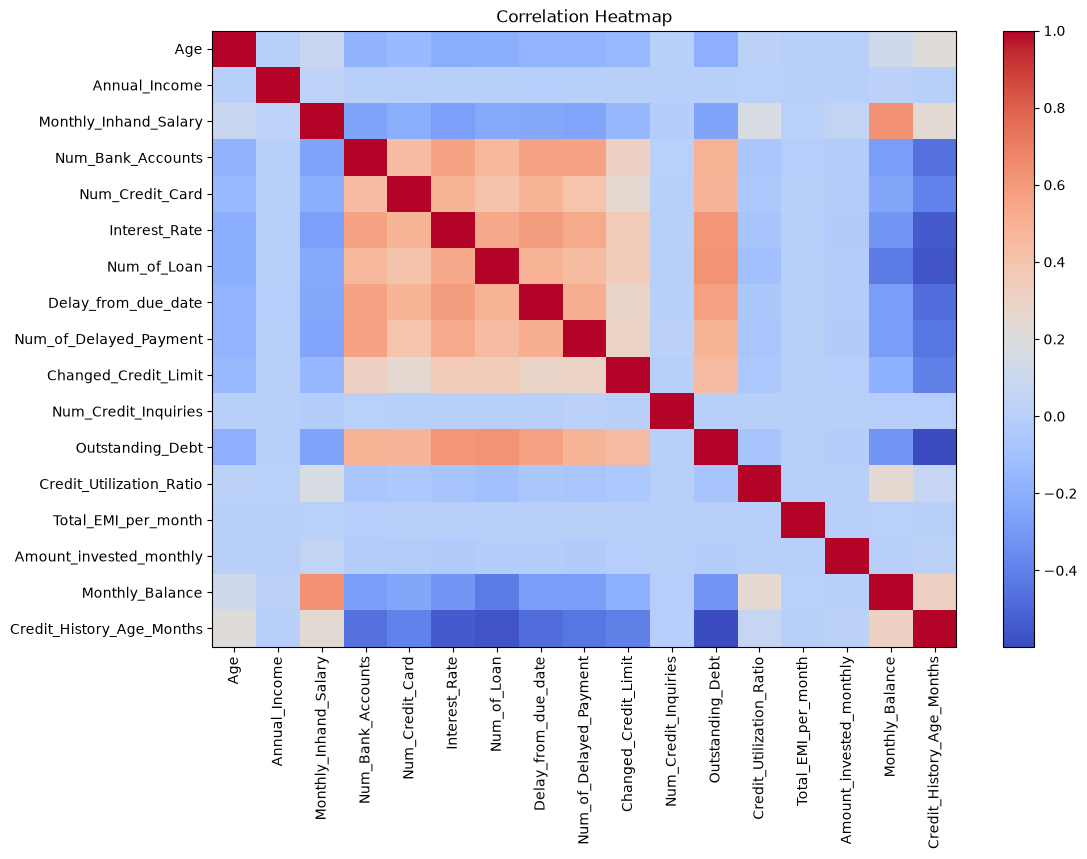

In [30]:
corr_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 8))
plt.imshow(df_clean[corr_cols].corr(), cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

Berdasarkan heatmap, beberapa fitur menunjukkan hubungan yang cukup kuat. `Outstanding_Debt` memiliki korelasi positif dengan `Interest_Rate`, `Num_of_Loan`, `Delay_from_due_date`, dan `Num_of_Delayed_Payment`, yang menunjukkan bahwa nasabah dengan beban utang lebih tinggi cenderung memiliki kondisi kredit yang lebih berisiko.

Di sisi lain, `Monthly_Balance` dan `Credit_History_Age_Months` cenderung berkorelasi negatif dengan beberapa indikator risiko seperti `Interest_Rate`, `Num_of_Loan`, dan `Outstanding_Debt`. Hal ini menunjukkan bahwa saldo bulanan yang lebih baik dan riwayat kredit yang lebih panjang cenderung berkaitan dengan kondisi kredit yang lebih sehat.

Secara umum, tidak semua fitur memiliki korelasi yang sangat tinggi, sehingga masih banyak informasi yang perlu dipelajari model dari kombinasi beberapa fitur, bukan hanya dari satu fitur saja.


## 6. Modelling Preparation

### 6.1 Split Feature and Target

In [31]:
X = df_clean.drop(columns=["Credit_Score"])
y = df_clean["Credit_Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumeric columns:")
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(numeric_cols)

print("\nCategorical columns:")
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
print(categorical_cols)

X shape: (25000, 23)
y shape: (25000,)

Numeric columns:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months']

Categorical columns:
['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


### Feature and Target Separation

Dataset dipisahkan menjadi fitur `X` dan target `y`. Target yang digunakan adalah `Credit_Score`, sedangkan seluruh kolom lainnya digunakan sebagai fitur untuk memprediksi performa kredit nasabah.

Setelah pemisahan, terdapat 23 fitur yang terdiri dari 17 fitur numerik dan 6 fitur kategorikal. Fitur numerik akan diproses menggunakan scaling, sedangkan fitur kategorikal akan diproses menggunakan encoding sebelum masuk ke model machine learning.


### 6.2 Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20000, 23)
X_test shape: (5000, 23)
y_train shape: (20000,)
y_test shape: (5000,)


In [33]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train target distribution:
Credit_Score
Standard    0.530
Poor        0.288
Good        0.182
Name: proportion, dtype: float64

Test target distribution:
Credit_Score
Standard    0.530
Poor        0.288
Good        0.182
Name: proportion, dtype: float64


### Train-Test Split Result

Hasil train-test split menunjukkan bahwa proporsi kelas pada data training dan testing tetap sama. Kelas `Standard` memiliki proporsi 53,0%, `Poor` sebesar 28,8%, dan `Good` sebesar 18,2%. Hal ini menunjukkan bahwa penggunaan stratified split berhasil menjaga distribusi target, sehingga data testing tetap representatif terhadap kondisi dataset awal.


### 6.3 Preprocessing Pipeline

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape:", X_test_processed.shape)

X_train processed shape: (20000, 5432)
X_test processed shape: (5000, 5432)


### Preprocessing Result

Hasil preprocessing menunjukkan bahwa data training berubah menjadi 20.000 baris dan 5.432 fitur, sedangkan data testing menjadi 5.000 baris dan 5.432 fitur. Jumlah fitur meningkat karena fitur kategorikal diubah menggunakan OneHotEncoder. Proses ini membuat seluruh fitur dapat digunakan oleh model machine learning.


## 7. Model Training & Experiment

### 7.1 Import Model and Evaluation Metrics

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### 7.2 Train Several Machine Learning Models

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []

for model_name, model in models.items():
    print("Training:", model_name)
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6946,0.696165,0.6946,0.693503
1,Decision Tree,0.6546,0.654333,0.6546,0.654443
2,Random Forest,0.7172,0.719535,0.7172,0.717710


### Model Training Experiment

Berdasarkan hasil eksperimen, Random Forest memberikan performa terbaik dibandingkan Logistic Regression dan Decision Tree. Random Forest memperoleh accuracy sebesar 71,72% dan F1-score sebesar 71,77%. Nilai ini menunjukkan bahwa Random Forest lebih mampu menangkap pola pada data kredit dibandingkan dua model lainnya.

Logistic Regression berada di posisi kedua dengan F1-score sebesar 69,35%, sedangkan Decision Tree memiliki performa paling rendah. Oleh karena itu, Random Forest dipilih sebagai model terbaik sementara untuk dievaluasi lebih lanjut menggunakan classification report dan confusion matrix.

## 8. Hyperparameter Tuning

Setelah perbandingan model dasar dilakukan, Random Forest menghasilkan performa terbaik dibandingkan Logistic Regression dan Decision Tree. Namun, performa model masih dapat ditingkatkan lagi, sehingga dilakukan hyperparameter tuning menggunakan Extra Trees Classifier.

Extra Trees dipilih karena termasuk model ensemble berbasis tree yang cocok digunakan untuk data tabular. Proses tuning dilakukan menggunakan RandomizedSearchCV agar pencarian kombinasi parameter terbaik dapat dilakukan lebih efisien. Metrik utama yang digunakan adalah weighted F1-score, karena target Credit Score memiliki beberapa kelas dengan jumlah data yang tidak sepenuhnya seimbang.

In [57]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

extra_trees_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(random_state=42, n_jobs=-1))
])

extra_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 20, 30, 40, 50],
    "model__min_samples_split": [2, 3, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [False, True],
    "model__criterion": ["gini", "entropy"]
}

extra_search = RandomizedSearchCV(
    estimator=extra_trees_pipeline,
    param_distributions=extra_param_dist,
    n_iter=25,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

extra_search.fit(X_train, y_train)

print("Best Parameters:")
print(extra_search.best_params_)

print("\nBest CV Weighted F1 Score:")
print(extra_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 50, 'model__criterion': 'entropy', 'model__bootstrap': False}

Best CV Weighted F1 Score:
0.7278128375408265


In [58]:
extra_trees_best_pipeline = extra_search.best_estimator_

y_pred_extra = extra_trees_best_pipeline.predict(X_test)

tuned_metrics = {
    "Model": "Tuned Model (Extra Trees)",
    "Accuracy": accuracy_score(y_test, y_pred_extra),
    "Precision": precision_score(y_test, y_pred_extra, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_extra, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_extra, average="weighted", zero_division=0)
}

tuned_metrics_df = pd.DataFrame([tuned_metrics])

final_results_df = pd.concat(
    [results_df, tuned_metrics_df],
    ignore_index=True
)

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6946,0.696165,0.6946,0.693503
1,Decision Tree,0.6546,0.654333,0.6546,0.654443
2,Random Forest,0.7172,0.719535,0.7172,0.717710
3,Tuned Model (Extra Trees),0.7398,0.740827,0.7398,0.740130


### Hyperparameter Tuning Result

Berdasarkan hasil tuning, Tuned Model menggunakan Extra Trees menghasilkan performa terbaik dibandingkan seluruh model dasar. Model ini memperoleh accuracy sebesar 0.7398 dan weighted F1-score sebesar 0.7401.

Hasil tersebut lebih tinggi dibandingkan Random Forest sebelumnya yang memperoleh weighted F1-score sebesar 0.7177. Oleh karena itu, Tuned Model menggunakan Extra Trees dipilih sebagai model final karena memberikan performa keseluruhan paling baik untuk klasifikasi Credit Score.

## 9. Best Model Evaluation

In [74]:
best_pipeline = extra_trees_best_pipeline
y_pred_best = best_pipeline.predict(X_test)

print("Best Model: Tuned Model (Extra Trees)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best Model: Tuned Model (Extra Trees)

Classification Report:
              precision    recall  f1-score   support

        Good       0.64      0.68      0.66       909
        Poor       0.75      0.72      0.73      1440
    Standard       0.77      0.77      0.77      2651

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



### Classification Report Analysis

Berdasarkan classification report, model terbaik yang digunakan pada project ini adalah Tuned Model menggunakan Extra Trees. Model ini memperoleh accuracy sebesar 0.74 pada data testing. Hasil ini menunjukkan bahwa model sudah cukup mampu mengklasifikasikan kategori Credit Score nasabah dengan baik.

Pada kelas Good, model memperoleh precision sebesar 0.64, recall sebesar 0.68, dan F1-score sebesar 0.66. Hasil ini menunjukkan bahwa kelas Good masih menjadi salah satu kelas yang cukup sulit diprediksi, karena jumlah datanya lebih sedikit dibandingkan kelas Standard.

Pada kelas Poor, model memperoleh precision sebesar 0.75, recall sebesar 0.72, dan F1-score sebesar 0.73. Artinya, model cukup baik dalam mengenali nasabah yang memiliki performa kredit buruk.

Pada kelas Standard, model memperoleh precision sebesar 0.77, recall sebesar 0.77, dan F1-score sebesar 0.77. Kelas ini memiliki performa paling stabil karena jumlah datanya paling banyak dibandingkan kelas lainnya.

Secara keseluruhan, weighted average F1-score sebesar 0.74 menunjukkan bahwa Tuned Model menggunakan Extra Trees memberikan performa terbaik dibandingkan model yang telah diuji sebelumnya.

In [75]:
cm = confusion_matrix(y_test, y_pred_best, labels=["Good", "Poor", "Standard"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Good", "Actual Poor", "Actual Standard"],
    columns=["Predicted Good", "Predicted Poor", "Predicted Standard"]
)

cm_df

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,618,15,276
Actual Poor,64,1036,340
Actual Standard,277,329,2045


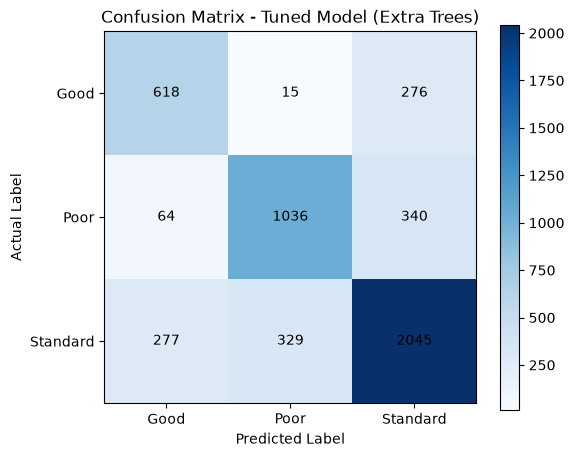

In [76]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Tuned Model (Extra Trees)")
plt.colorbar()

labels = ["Good", "Poor", "Standard"]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Confusion Matrix Analysis

Berdasarkan confusion matrix, Tuned Model menggunakan Extra Trees berhasil memprediksi 618 nasabah Good, 1.036 nasabah Poor, dan 2.045 nasabah Standard dengan benar. Hasil prediksi benar tersebut berada pada diagonal utama confusion matrix.

Pada kelas Good, sebanyak 618 data berhasil diprediksi dengan benar. Namun, masih terdapat 276 data Good yang diprediksi sebagai Standard dan 15 data Good yang diprediksi sebagai Poor. Hal ini menunjukkan bahwa sebagian nasabah dengan kategori Good masih memiliki pola yang cukup mirip dengan kategori Standard.

Pada kelas Poor, sebanyak 1.036 data berhasil diprediksi dengan benar. Namun, terdapat 340 data Poor yang diprediksi sebagai Standard dan 64 data Poor yang diprediksi sebagai Good. Hal ini menunjukkan bahwa model masih cukup sulit membedakan sebagian nasabah Poor dengan kategori Standard.

Pada kelas Standard, model berhasil memprediksi 2.045 data dengan benar. Jumlah ini menjadi prediksi benar paling tinggi dibandingkan kelas lainnya. Namun, masih terdapat 277 data Standard yang diprediksi sebagai Good dan 329 data Standard yang diprediksi sebagai Poor.

Secara keseluruhan, model bekerja paling baik pada kelas Standard karena jumlah datanya paling banyak. Kesalahan prediksi paling sering terjadi antara kelas Good dan Standard, serta antara kelas Poor dan Standard. Hal ini masih wajar karena nasabah pada kategori tengah sering memiliki karakteristik keuangan yang mirip dengan dua kategori lainnya.

## 10. Save Best Model

### 10.1 Save Model with Joblib

In [77]:
import joblib
import os

joblib.dump(best_pipeline, "best_credit_score_model.pkl", compress=3)

print("Model saved:", os.path.exists("best_credit_score_model.pkl"))
print("Model size:", round(os.path.getsize("best_credit_score_model.pkl") / 1024 / 1024, 2), "MB")

Model saved: True
Model size: 28.39 MB


In [78]:
import os

print("Model saved:", os.path.exists("best_credit_score_model.pkl"))

Model saved: True


### Save Best Model

Model terbaik yang digunakan pada project ini adalah Tuned Model menggunakan Extra Trees. Model disimpan dalam bentuk pipeline lengkap yang sudah mencakup proses preprocessing dan model machine learning yang sudah dilatih.

Dengan menyimpan model dalam bentuk pipeline, model dapat langsung menerima data input mentah dan melakukan prediksi tanpa perlu preprocessing manual secara terpisah. Model disimpan dalam format pkl menggunakan joblib agar dapat digunakan kembali pada file inference dan aplikasi Streamlit.

## 11. Test Load Model and Inference

In [79]:
loaded_model = joblib.load("best_credit_score_model.pkl")

sample_data = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample_data)

print("Prediction result:", sample_prediction[0])

Prediction result: Good


In [80]:
sample_data

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_Months
9029,June,46.0,Scientist,45764.14,3118.399167,6.0,5.0,11.0,2.0,"Debt Consolidation Loan, and Credit-Builder Loan",11,17.0,9.31,3.0,Good,146.1,25.53853,No,62.194569,138.572608,Low_spent_Small_value_payments,466.660531,374.0


### Model Loading and Inference Test

Model yang sudah disimpan berhasil dimuat kembali menggunakan joblib. Pengujian dilakukan menggunakan satu data sampel dari data testing. Hasil prediksi menunjukkan bahwa pipeline dapat digunakan untuk melakukan inference secara langsung.

Hal ini menunjukkan bahwa model yang disimpan sudah siap digunakan untuk tahap deployment.


## 12. Deployment Testing with Test Cases

Setelah model terbaik berhasil disimpan, pengujian deployment dilakukan menggunakan beberapa test case yang mewakili setiap kelas Credit Score, yaitu Good, Poor, dan Standard. Test case tersebut disimpan dalam file CSV, kemudian dimasukkan ke pipeline model yang sudah disimpan untuk melihat apakah model dapat memprediksi setiap kelas dengan benar.

Hasil pengujian menunjukkan bahwa model berhasil memprediksi test case sesuai dengan label yang diharapkan. Dengan demikian, model yang sudah disimpan dapat digunakan untuk proses inference dan deployment pada aplikasi Streamlit.

In [81]:
import pandas as pd
import joblib
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

model = joblib.load("best_credit_score_model.pkl")

test_cases = pd.read_csv("test_cases.csv")
test_cases

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_Months,Expected_Result
0,January,42.0,Teacher,19214.965,1730.247083,0.0,4.0,11.0,0.0,Unknown,10,10.0,4.18,0.0,Good,498.81,37.600265,No,0.000000,217.780472,Unknown,245.244236,345.0,Good
1,April,32.0,Architect,14995.290,3118.399167,7.0,5.0,28.0,5.0,"Auto Loan, Payday Loan, Mortgage Loan, Payday Loan, and Student Loan",39,24.0,20.85,7.0,Bad,4593.28,29.968714,Yes,60.535964,54.738541,Low_spent_Medium_value_payments,278.586245,38.0,Poor
2,February,53.0,Writer,111090.060,9192.505000,0.0,5.0,11.0,3.0,"Payday Loan, Credit-Builder Loan, and Auto Loan",-1,3.0,11.99,1.0,Good,575.32,25.360743,No,149.079658,436.737285,Low_spent_Medium_value_payments,613.433557,330.0,Standard


In [82]:
customer_info_cols = [
    "Month",
    "Age",
    "Occupation",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Monthly_Balance",
    "Credit_History_Age_Months"
]

credit_account_cols = [
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Type_of_Loan",
    "Num_Credit_Inquiries",
    "Credit_Mix"
]

payment_info_cols = [
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Payment_of_Min_Amount",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Payment_Behaviour",
    "Expected_Result"
]

display(test_cases[customer_info_cols])
display(test_cases[credit_account_cols])
display(test_cases[payment_info_cols])

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Monthly_Balance,Credit_History_Age_Months
0,January,42.0,Teacher,19214.965,1730.247083,245.244236,345.0
1,April,32.0,Architect,14995.290,3118.399167,278.586245,38.0
2,February,53.0,Writer,111090.060,9192.505000,613.433557,330.0


,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix
0,0.0,4.0,11.0,0.0,Unknown,0.0,Good
1,7.0,5.0,28.0,5.0,"Auto Loan, Payday Loan, Mortgage Loan, Payday Loan, and Student Loan",7.0,Bad
2,0.0,5.0,11.0,3.0,"Payday Loan, Credit-Builder Loan, and Auto Loan",1.0,Good


,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Expected_Result
0,10,10.0,4.18,498.81,37.600265,No,0.000000,217.780472,Unknown,Good
1,39,24.0,20.85,4593.28,29.968714,Yes,60.535964,54.738541,Low_spent_Medium_value_payments,Poor
2,-1,3.0,11.99,575.32,25.360743,No,149.079658,436.737285,Low_spent_Medium_value_payments,Standard


In [83]:
X_test_cases = test_cases.drop(columns=["Expected_Result"])
expected_result = test_cases["Expected_Result"]

prediction_result = model.predict(X_test_cases)
prediction_probability = model.predict_proba(X_test_cases)

deployment_result = test_cases.copy()
deployment_result["Prediction_Result"] = prediction_result
deployment_result["Status"] = np.where(
    deployment_result["Expected_Result"] == deployment_result["Prediction_Result"],
    "Passed",
    "Failed"
)

deployment_result[["Expected_Result", "Prediction_Result", "Status"]]

,Expected_Result,Prediction_Result,Status
0,Good,Good,Passed
1,Poor,Poor,Passed
2,Standard,Standard,Passed


In [84]:
probability_df = pd.DataFrame(
    prediction_probability,
    columns=[f"Probability_{label}" for label in model.classes_]
)

final_test_result = pd.concat(
    [
        deployment_result[["Expected_Result", "Prediction_Result", "Status"]],
        probability_df
    ],
    axis=1
)

final_test_result

,Expected_Result,Prediction_Result,Status,Probability_Good,Probability_Poor,Probability_Standard
0,Good,Good,Passed,0.932500,0.004583,0.062917
1,Poor,Poor,Passed,0.002500,0.937788,0.059712
2,Standard,Standard,Passed,0.080569,0.009963,0.909468


In [85]:
for i, row in deployment_result.iterrows():
    print("=" * 40)
    print(f"Test Case {i+1} = {row['Expected_Result']} Credit Score")
    print(f"Expected Result: {row['Expected_Result']}")
    print(f"Prediction Result: {row['Prediction_Result']}")
    print(f"Status: {row['Status']}")
    print("=" * 40)
    print()

Test Case 1 = Good Credit Score
Expected Result: Good
Prediction Result: Good
Status: Passed

Test Case 2 = Poor Credit Score
Expected Result: Poor
Prediction Result: Poor
Status: Passed

Test Case 3 = Standard Credit Score
Expected Result: Standard
Prediction Result: Standard
Status: Passed



## 13. Notebook Conclusion

### Conclusion

Berdasarkan proses eksplorasi data dan modelling yang telah dilakukan, dataset Credit Score membutuhkan beberapa tahap preprocessing, seperti menghapus kolom identitas, mengubah kolom numerik yang masih berbentuk teks, menangani missing value, membersihkan nilai kategorikal yang tidak valid, menangani nilai numerik yang tidak realistis, melakukan scaling pada fitur numerik, dan encoding pada fitur kategorikal.

Beberapa model machine learning diuji pada project ini, yaitu Logistic Regression, Decision Tree, Random Forest, dan Tuned Model menggunakan Extra Trees. Berdasarkan hasil eksperimen akhir, Tuned Model menggunakan Extra Trees menghasilkan performa terbaik dengan accuracy sebesar 0.7398 dan weighted F1-score sebesar 0.7401. Oleh karena itu, model ini dipilih sebagai model final.

Model final kemudian disimpan dalam format pkl dan digunakan untuk proses inference serta deployment menggunakan Streamlit. Pengujian deployment juga dilakukan menggunakan test case yang mewakili kelas Good, Poor, dan Standard. Hasilnya menunjukkan bahwa model dapat memprediksi test case dengan baik, sehingga pipeline model sudah siap digunakan untuk tahap deployment.